<a href="https://colab.research.google.com/github/IgorAkO/Simulative_ML/blob/main/2%20DatAnPyt/S_ML_2_3_8_dataviz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://gist.githubusercontent.com/andron23/f965229448f815dffa9a61bd701c0538/raw/5e309e67ae6515fd09516cbe18a4b21189052617/coderun.csv

--2026-04-08 05:38:26--  https://gist.githubusercontent.com/andron23/f965229448f815dffa9a61bd701c0538/raw/5e309e67ae6515fd09516cbe18a4b21189052617/coderun.csv
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 779437 (761K) [text/plain]
Saving to: ‘coderun.csv’

coderun.csv         100%[===================>] 761.17K  --.-KB/s    in 0.05s   

2026-04-08 05:38:26 (16.3 MB/s) - ‘coderun.csv’ saved [779437/779437]



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('coderun.csv')

df['ymd'] = pd.to_datetime(df['created_at']).dt.date

df['ym'] = pd.to_datetime(df['created_at']).dt.strftime('%Y-%m')

### Вопрос №1
Постройте график динамики количества попыток по дням, а также наглядно покажите связь со средним значением. Выберите верные утверждения - что можно сказать по этому графику.

In [ ]:
df_runs_by_date = df.groupby('ymd')['ymd'].agg({
    'count'
}).reset_index()

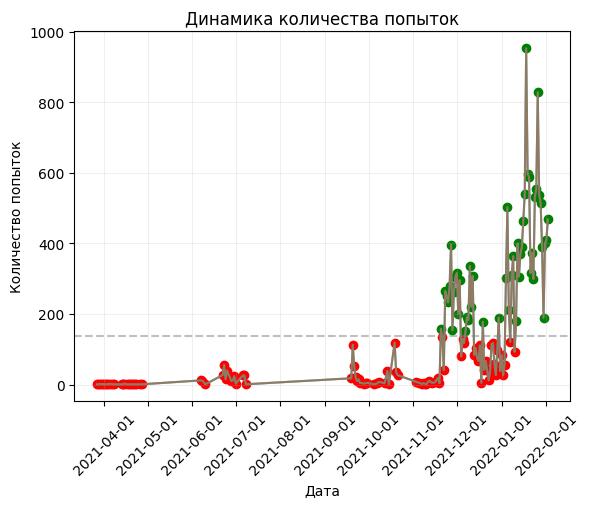

In [ ]:
plt.plot(df_runs_by_date['ymd'], df_runs_by_date['count'])

mean_value = df_runs_by_date['count'].mean()

df_runs_by_date['is_lower_than_avg'] = df_runs_by_date['count'] < mean_value

df_lower = df_runs_by_date[df_runs_by_date['is_lower_than_avg'] == True]
df_higher = df_runs_by_date[df_runs_by_date['is_lower_than_avg'] == False]

plt.plot(df_runs_by_date['ymd'],df_runs_by_date['count'], alpha=0.5)
plt.scatter(df_lower['ymd'], df_lower['count'], color='red')
plt.scatter(df_higher['ymd'], df_higher['count'], color='green')

plt.title('Динамика количества попыток')

plt.xlabel('Дата')
plt.ylabel('Количество попыток')

plt.xticks(plt.xticks()[0], rotation=45)
plt.grid(alpha=0.2)
plt.axhline(y=mean_value, alpha=0.5, linestyle='--', color='gray')

# Было несколько дней со значением 800
# Пик приходится на январь-февраль 2022

### Вопрос №2
На одном графике изобразите два боксплота по дневному количеству попыток за весь период с разбивкой по языкам. Выберите верные утверждения - что можно сказать по этому графику.

In [ ]:
df_runs_by_date_l = df.groupby(['ymd', 'language_id']).agg(count=('ymd', 'count')).reset_index()

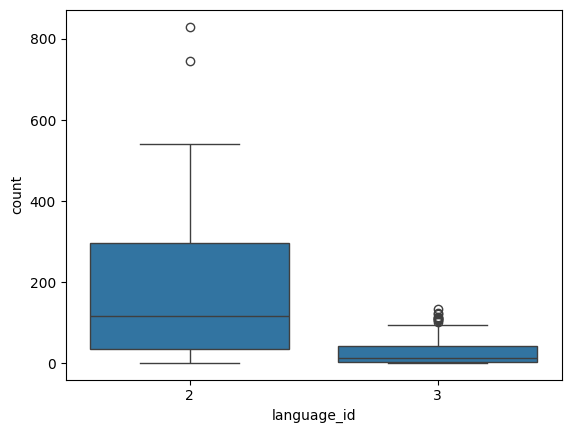

In [ ]:
sns.boxplot(data=df_runs_by_date_l, y="count", x="language_id");

# У языка с Id=2 большая вариативность количества попыток - в некоторые дни делается немного попыток, а в некоторые много
# Нельзя точно сказать, в какой группе больше количество измерений

### Вопрос №3
На одном графике изобразите боксплоты, которые показывают распределение по дневному количеству попыток за период с декабря 2021 года и с разбивкой по месяцам, а внутри каждого месяца - по языкам. Выберите верные утверждения - что можно сказать по этому графику.

In [ ]:
df3 = df[df['ym'] >= '2021-12'].groupby(['ym', 'ymd', 'language_id'])['problem_id'].agg({'count'}).reset_index()
df3.head(3)


,ym,ymd,language_id,count
0,2021-12,2021-12-01,2,310
1,2021-12,2021-12-01,3,6
2,2021-12,2021-12-02,2,164


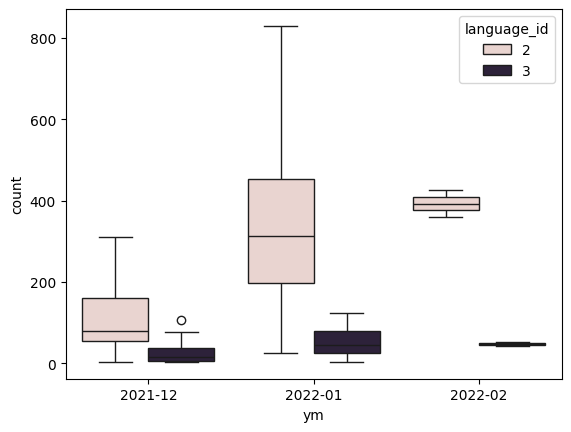

In [ ]:
sns.boxplot(data=df3, y='count', x='ym', hue='language_id');
# В последний месяц очень сильно снизилась вариативность дневного количества попыток в обеих группах.

### Вопрос №4
Вы хотите проверить гипотезу о том, что чем позже пользователь регистрировался на платформе, тем большее количество уникальных задач он решал. Отобразите это на диаграмме рассеяния. Выберите верные утверждения - что можно сказать по этому графику.

In [ ]:
df4 = df.groupby('user_id')['problem_id'].agg({'nunique'}).reset_index()
df4.head(4)

,user_id,nunique
0,1,2
1,2,4
2,3,3
3,4,1


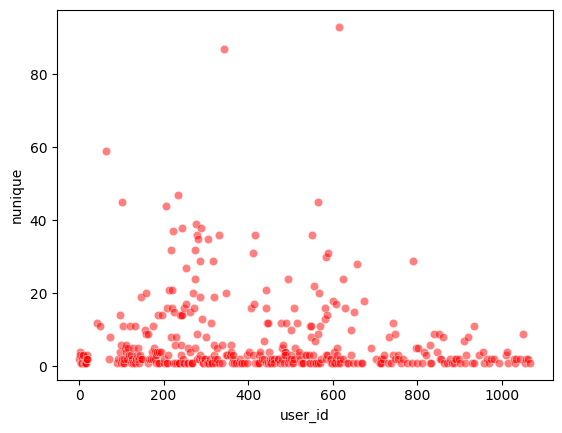

In [ ]:
sns.scatterplot(data=df4, x='user_id', y='nunique', color='red', alpha=0.5);
# Среди пользователей, которые зарегестрировались позже, меньше людейй, которые решали много задач.
# В каждой 'сотне' пользователей есть отдельные люди, кто много решал задачи.
# Основная масса пользователей решала до 20 задач.
# Нельзя судить о какой-то линейной связи между этими переменными.

### Вопрос №5
Вы хотите проверить гипотезу о том, что есть корреляция между средним количеством попыток, которые делает пользователь для решения одной задачи, максимальным количеством попыток и минимальным. Проверьте эту гипотезу с помощью построения матрицы корреляций. Выберите верные утверждения - что можно сказать по этому графику.

In [ ]:
df5 = df.groupby(['user_id', 'problem_id'])['ymd'].agg({'count'}).reset_index()
df5 = df5.groupby('user_id')['count'].agg({'mean', 'max', 'min'}).reset_index()
df5.head(3)

,user_id,min,max,mean
0,1,1,1,1.00
1,2,1,171,66.25
2,3,1,1,1.00


<Axes: >

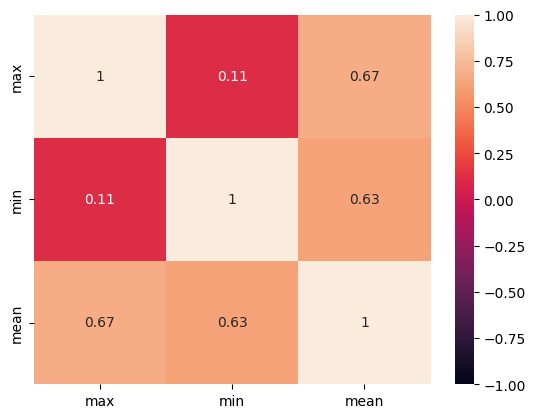

In [ ]:
sns.heatmap(df5[['max', 'min','mean']].corr(), annot=True, cbar=True, vmin=-1, vmax=1)
# Среднее количество попыток примерно одинаково коррелирует и с максиальным, и с минимальным.
# Есть только одна пара признаков со слабой корреляцией.
# Если считать корреляцию более 60% сильной, то есть как минимум 2 пары признаков с сильной корреляцией.

### Вопрос №6
Постройте график n-day retention с разбивкой по когортам до 30 n-дня. Под когортой понимайте год и месяц решения первой задачи каждым пользователем - от этого момента начинается отсчет. Учитывайте только когорты после ноября 2021 года включительно. График стройте не по процентам retention, а по количеству уникальных пользователей в каждый n-день в каждой когорте. Выберите верные утверждения - что можно сказать по этому графику.

In [ ]:
df6 = df[['id',	'created_at',	'problem_id',	'user_id',	'language_id']].copy()
df6['ymd'] = pd.to_datetime(df6['created_at']).dt.normalize()
df6['start_ymd'] = df6.groupby('user_id')['ymd'].transform('min')

df6['cohort'] = df6['start_ymd'].dt.strftime('%Y-%m')
df6['start_ymd'] = (df6['ymd'] - df6['start_ymd']).dt.days
df6 = df6[df6['cohort'] >= '2021-11']

retention = df6.groupby(['cohort', 'start_ymd'])['user_id'].agg({'nunique'}).reset_index()
#df6.head(2)
retention.head(10)

,cohort,start_ymd,nunique
0,2021-11,0,91
1,2021-11,1,24
2,2021-11,2,11
3,2021-11,3,9
4,2021-11,4,8
5,2021-11,5,7
6,2021-11,6,10
7,2021-11,7,6
8,2021-11,8,6
9,2021-11,9,4


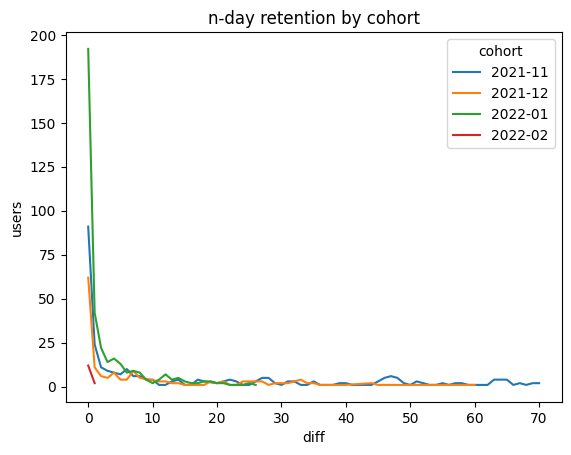

In [ ]:
fig = sns.lineplot(data=retention, x='start_ymd', y='nunique', hue='cohort');
#Разные когорты (Месяцы)

plt.xlabel('diff')
plt.ylabel('users')
plt.title('n-day retention by cohort')

plt.show()

# Среди всех когорт наблюдается слабое удержание - примерно на 10 день посещения падают почти до нуля.

### Вопрос №7
Для оценки распределения хорошо использовать не только boxplot, но и скрипичную диаграмму - violinplot. Она дает сильно больше информации, чем простой ящик с усами. Например, такой график есть в seaborn.

Отобразите на графике распределение числа уникальных пользователей, сгруппированных по датам совершения попытки, в разрезе языков.

Выберите верные утверждения - что можно сказать по этому графику.

In [ ]:
df7 = df.groupby(['ymd', 'language_id'])['user_id'].agg({'nunique'}).reset_index()
df7.head(2)

,ymd,language_id,nunique
0,2021-03-27,3,1
1,2021-03-28,3,1


<Axes: xlabel='language_id', ylabel='nunique'>

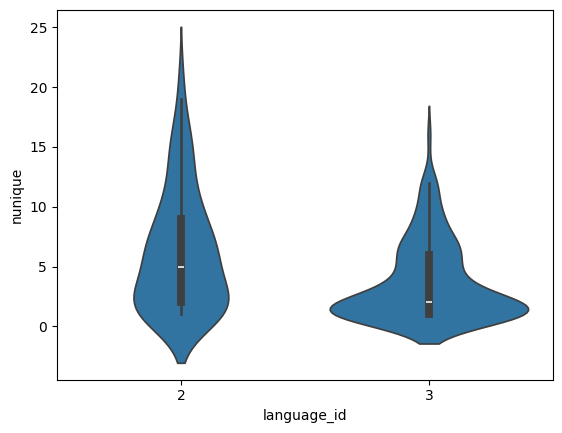

In [ ]:
sns.violinplot(x=df7['language_id'], y=df7['nunique'])
# Есть некоторое количество дней, в которых задачи с языком 2 решает больше пользователей, чем с языком 3.
# Первый квартиль между двумя группами почти совпадает.
# Положение точки медианы между 1 и 3 квартилем напрямую зависит от равномерности распределения данных внутри этого промежутка: чем более равномерные данные, тем ближе точка медианы к центру.
# Между первым и третьим квартилем распределение данных внутри 2 язяка более равномерное чем внутри 3.

In [ ]:
df.head(3)

,id,created_at,problem_id,user_id,language_id,ymd,ym
0,1,2021-04-07 06:06:20.000,13,10,3,2021-04-07,2021-04
1,2,2021-03-31 07:10:06.000,15,13,3,2021-03-31,2021-03
2,3,2021-04-04 14:55:26.000,1,6,3,2021-04-04,2021-04
